In [1]:
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple, defaultdict
import matplotlib.pyplot as plt
%matplotlib inline

import mlagents_envs
from mlagents_envs.environment import UnityEnvironment, ActionTuple
from mlagents_envs.side_channel.engine_configuration_channel import EngineConfigurationChannel


In [2]:
BUFFER_SIZE = int(1e5)  # replay buffer size
BATCH_SIZE = 64         # minibatch size
GAMMA = 0.99            # discount factor
TAU = 1e-3              # for soft update of target parameters
LR = 5e-4               # learning rate 
UPDATE_EVERY = 4        # how often to update the network

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
channel = EngineConfigurationChannel()
env = UnityEnvironment(file_name=None, seed=0, side_channels=[channel]) # press play the game in the editor 
#faster simulation speed
channel.set_configuration_parameters(time_scale=20.0)
env.reset()

In [ ]:
# We will only consider the first Behavior
behavior_name = list(env.behavior_specs)[0]
print(f"Name of the behavior : {behavior_name}")
spec = env.behavior_specs[behavior_name]

Name of the behavior : Basic?team=0


In [5]:
##random agent

all_rewards = []
for episode in range(10):
  env.reset()
  decision_steps, terminal_steps = env.get_steps(behavior_name)
  tracked_agent = -1 # -1 indicates not yet tracking
  done = False # For the tracked_agent
  episode_rewards = 0 # For the tracked_agent
  while not done:
    # Track the first agent we see if not tracking
    # Note : len(decision_steps) = [number of agents that requested a decision]
    if tracked_agent == -1 and len(decision_steps) >= 1:
      tracked_agent = decision_steps.agent_id[0]

    # Generate an action for all agents
    action = spec.action_spec.random_action(len(decision_steps))

    # Set the actions
    env.set_actions(behavior_name, action)

    # Move the simulation forward
    env.step()

    # Get the new simulation results
    decision_steps, terminal_steps = env.get_steps(behavior_name)
    if tracked_agent in decision_steps: # The agent requested a decision
      episode_rewards += decision_steps[tracked_agent].reward
    if tracked_agent in terminal_steps: # The agent terminated its episode
      episode_rewards += terminal_steps[tracked_agent].reward
      done = True
      all_rewards.append(episode_rewards)
      print(f"\rTotal rewards for episode {episode} is {episode_rewards:.4f}", end="")


Total rewards for episode 9 is -0.2600

In [6]:
class QNetwork(nn.Module):
    """Actor (Policy) Model."""

    def __init__(self, state_size, action_size, seed):
        """Initialize parameters and build model.
        Params
        ======
            state_size (int): Dimension of each state
            action_size (int): Dimension of each action
            seed (int): Random seed
        """
        super(QNetwork, self).__init__()
        self.state_size = state_size
        self.action_size = action_size
        self.seed = torch.manual_seed(seed)
        self.model = nn.Sequential(
            nn.Linear(self.state_size, self.state_size*4),
            nn.ReLU(),
            nn.Linear(self.state_size*4, self.state_size*2),
            nn.ReLU(),
            nn.Linear(self.state_size*2, self.action_size)  
        )

    def forward(self, state):
        """Build a network that maps state -> action values."""
        out = self.model(state)
        return out


In [ ]:
class ReplayBuffer:
    """Fixed-size buffer to store experience tuples."""

    def __init__(self, buffer_size, batch_size, seed):
        """Initialize a ReplayBuffer object.

        Params
        ======
            buffer_size (int): maximum size of buffer
            batch_size (int): size of each training batch
            seed (int): random seed
        """
        self.action_size = action_size
        self.memory = deque(maxlen=buffer_size)  
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done", "mask_next"])
        self.seed = random.seed(seed)
    
    def add(self, state, action, reward, next_state, done, mask_next):
        """Add a new experience to memory."""
        e = self.experience(state, action, reward, next_state, done, mask_next)
        self.memory.append(e)
    
    def sample(self):
        """Randomly sample a batch of experiences from memory."""
        experiences = random.sample(self.memory, k=self.batch_size)

        states = torch.from_numpy(np.vstack([e.state for e in experiences if e is not None])).float().to(device)
        actions = torch.from_numpy(np.vstack([e.action for e in experiences if e is not None])).long().to(device)
        rewards = torch.from_numpy(np.vstack([e.reward for e in experiences if e is not None])).float().to(device)
        next_states = torch.from_numpy(np.vstack([e.next_state for e in experiences if e is not None])).float().to(device)
        dones = torch.from_numpy(np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)).float().to(device)
        mask_next = torch.from_numpy(np.vstack([e.mask_next for e in experiences if e is not None]).astype(np.uint8)).bool().to(device)
  
        return (states, actions, rewards, next_states, dones, mask_next)

    def __len__(self):
        """Return the current size of internal memory."""
        return len(self.memory)

In [ ]:
class Agent():
    """Interacts with and learns from the environment."""

    def __init__(self, state_size, action_size, seed):
        """Initialize an Agent object.
        
        Params
        ======
            state_size (int): dimension of each state
            action_size (int): dimension of each action
            seed (int): random seed
        """
        self.state_size = state_size
        self.action_size = action_size
        self.seed = random.seed(seed)

        # Q-Network
        self.qnetwork_local = QNetwork(state_size, action_size, seed).to(device)
        self.qnetwork_target = QNetwork(state_size, action_size, seed).to(device)
        self.optimizer = optim.Adam(self.qnetwork_local.parameters(), lr=LR)

        # Replay memory
        self.memory = ReplayBuffer(action_size, BUFFER_SIZE, BATCH_SIZE, seed)
        # Initialize time step (for updating every UPDATE_EVERY steps)
        self.t_step = 0
    
    def step(self, state, action, reward, next_state, done, mask_next):
        # Save experience in replay memory
        self.memory.add(state, action, reward, next_state, done, mask_next)
        
        # Learn every UPDATE_EVERY time steps.
        self.t_step = (self.t_step + 1) % UPDATE_EVERY
        if self.t_step == 0 and len(self.memory) > BATCH_SIZE:
            # If enough samples are available in memory, get random subset and learn
            experiences = self.memory.sample()
            self.learn(experiences, GAMMA)

    def act(self, obs, mask, eps=0.):
        """obs: (n, state_size) float32,(n: number of agents)
          mask: (n, action_size) bool, True = illegal
          Note: Mask is true when action is unavailable  
        """
        
        obs_t  = torch.as_tensor(obs,  dtype=torch.float32, device=device)
        mask_t = torch.as_tensor(mask, dtype=torch.bool,    device=device)

        with torch.no_grad():
            #fill q values of illegal actions with -1e9, so that they are never selected
            q = self.qnetwork_local(obs_t).masked_fill(mask_t, -1e9)

        greedy  = q.argmax(dim=1)
        #select random action from legal actions. The probability of selecting each legal action is equal.
        # Probability of selecting illegal actions is 0.

        rand    = torch.multinomial((~mask_t).float(), 1).squeeze(1)
        explore = torch.rand(len(obs), device=device) < eps

        return torch.where(explore, rand, greedy).cpu().numpy()

    def learn(self, experiences, gamma):
        """Update value parameters using given batch of experience tuples.

        Params
        ======
            experiences (Tuple[torch.Tensor]): tuple of (s, a, r, s', done) tuples 
            gamma (float): discount factor
        """
        states, actions, rewards, next_states, dones, next_masks = experiences

        ## compute and minimize the loss
        
        self.optimizer.zero_grad()
        out = self.qnetwork_local(states)
        Q_curr = torch.gather(out, dim =-1, index = actions)
        with torch.no_grad():
            q_next = self.qnetwork_target(next_states).masked_fill(next_masks, -1e9)
            Q_next = q_next.max(dim=-1, keepdim=True)[0]
            target = rewards + (gamma*Q_next*(1-dones)) 
                   
        loss = F.mse_loss(Q_curr, target)
        loss.backward()
        self.optimizer.step()


        # ------------------- update target network ------------------- #
        self.soft_update(self.qnetwork_local, self.qnetwork_target, TAU)                     

    def soft_update(self, local_model, target_model, tau):
        """Soft update model parameters.
        θ_target = τ*θ_local + (1 - τ)*θ_target

        Params
        ======
            local_model (PyTorch model): weights will be copied from
            target_model (PyTorch model): weights will be copied to
            tau (float): interpolation parameter 
        """
        for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
            target_param.data.copy_(tau*local_param.data + (1.0-tau)*target_param.data)


In [9]:
def masked_q(q, mask):
    # mask is True where the action is UNAVAILABLE
    return q.masked_fill(mask, float('-inf'))    

In [ ]:
def train(agent, n_steps=40_000, eps_start=1.0, eps_end=0.01, eps_decay=0.995):
    pending    = {}                      # agent_id -> (state, action)
    ep_return  = defaultdict(float)
    scores, window = [], deque(maxlen=100)
    eps = eps_start
    env.reset()

    for t in range(n_steps):
        decision_steps, terminal_steps = env.get_steps(behavior_name)

        # --- agents whose episode just ended ---
        for agent_id in terminal_steps:
            ts = terminal_steps[agent_id]
            if agent_id in pending:
                #remove the s,a pair for the agent whose episode just ended
                s, a = pending.pop(agent_id)
                done = not ts.interrupted          # timeout still bootstraps
                agent.step(s, a, ts.reward, ts.obs[0], done,
                           np.zeros(action_size, dtype=bool))
            ep_return[agent_id] += ts.reward
            window.append(ep_return[agent_id])
            scores.append(ep_return[agent_id])
            ep_return[agent_id] = 0.0
            eps = max(eps_end, eps_decay * eps)

        # --- agents needing an action ---
        if len(decision_steps) > 0:
            obs = decision_steps.obs[0]
            n   = len(decision_steps)
            mask = (np.zeros((n, action_size), dtype=bool)
                    if decision_steps.action_mask is None
                    else decision_steps.action_mask[0])

            #actions for all agents which need a decision
            actions = agent.act(obs, mask, eps)

            for agent_id in decision_steps:
                i = decision_steps.agent_id_to_index[agent_id]
                r = decision_steps[agent_id].reward
                if agent_id in pending:
                    s, a = pending[agent_id]
                    agent.step(s, a, r, obs[i], False, mask[i])
                ep_return[agent_id] += r
                pending[agent_id] = (obs[i].copy(), actions[i])

            env.set_actions(behavior_name,
                            ActionTuple(discrete=actions.reshape(-1, 1).astype(np.int32)))

        env.step()

        if t % 5000 == 0 and window:
            print(f"step {t}\teps {eps:.3f}\tavg return {np.mean(window):.3f}")

        if len(window) == window.maxlen and round(np.mean(window), 2) >= 0.93:
            print(f"\nEnvironment solved in {t} steps!\tAverage Return: {np.mean(window):.3f}")
            torch.save(agent.qnetwork_local.state_dict(), 'checkpoint.pth')
            break

    return scores

In [11]:
state_size = spec.observation_specs[0].shape[0]
action_size = spec.action_spec.discrete_branches[0]
agent = Agent(state_size=state_size, action_size=action_size, seed=0)

In [12]:
scores = train(agent)

step 5000	eps 0.503	avg return 0.140
step 10000	eps 0.261	avg return 0.561

Environment solved in 13639 steps!	Average Return: 0.925


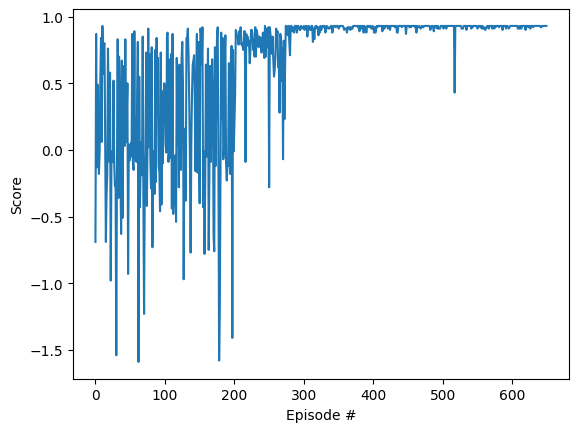

In [14]:
# plot the scores
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()

In [16]:
agent.qnetwork_local.load_state_dict(torch.load('checkpoint.pth'))

<All keys matched successfully>

In [ ]:
#trained agent
#back to normal speed
channel.set_configuration_parameters(time_scale=1.0)
all_rewards = []
for episode in range(20):
  env.reset()
  decision_steps, terminal_steps = env.get_steps(behavior_name)
  tracked_agent = -1 # -1 indicates not yet tracking
  done = False # For the tracked_agent
  episode_rewards = 0 # For the tracked_agent
  while not done:
    # Track the first agent we see if not tracking
    # Note : len(decision_steps) = [number of agents that requested a decision]
    if tracked_agent == -1 and len(decision_steps) >= 1:
      tracked_agent = decision_steps.agent_id[0]

    # Generate an action for all agents
    decision_mask = decision_steps.action_mask[0] if decision_steps.action_mask is not None else np.zeros((len(decision_steps), action_size), dtype=bool)
    actions = agent.act(decision_steps.obs[0], decision_mask)

    # Set the actions
    env.set_actions(behavior_name, ActionTuple(discrete=actions.reshape(-1, 1).astype(np.int32)))

    # Move the simulation forward
    env.step()

    # Get the new simulation results
    decision_steps, terminal_steps = env.get_steps(behavior_name)
    if tracked_agent in decision_steps: # The agent requested a decision
      episode_rewards += decision_steps[tracked_agent].reward
    if tracked_agent in terminal_steps: # The agent terminated its episode
      episode_rewards += terminal_steps[tracked_agent].reward
      done = True
      all_rewards.append(episode_rewards)
      print(f"\rTotal rewards for episode {episode} is {episode_rewards:.4f}", end="")

print(f"\nAverage rewards over 20 episodes is {np.mean(all_rewards):.4f}")


Total rewards for episode 19 is 0.9300
Average rewards over 20 episodes is 0.9300


In [21]:
env.close()
print("Closed environment")

Closed environment
